<a href="https://colab.research.google.com/github/CesarAr0504/Arredondo_Restrepo_Lab_Sen/blob/main/Arredondo_Restrepo_Practica_3_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Parte 2: Analisis de señales EMG para imagineria motora
##Integrantes:
## Cesar Arredondo
##Alejandro Restrepo

##1. Objetivos

###General:
Aplicar herramientas de procesamiento y análisis estadístico sobre señales EEG de imaginería motora, con el fin de comparar la actividad cerebral asociada al movimiento imaginado de la mano izquierda y la mano derecha.

##Específicos:

- Cargar y organizar registros EEG de varios sujetos y distintos ensayos de imaginería motora.
- Filtrar la señal para resaltar el rango de frecuencias relevante en la tarea.
- Segmentar épocas de interés y calcular una medida representativa de amplitud mediante RMS por canal.
Comparar estadísticamente las respuestas entre imaginación de mano izquierda y derecha.
- Identificar canales con diferencias potencialmente significativas entre ambos grupos.

##2. Resumen

En esta práctica se desarrolla un flujo de análisis para señales cerebrales de imaginería motora usando Python y la librería MNE. Primero se cargan archivos .set correspondientes a varios sujetos, se seleccionan los runs de interés y se aplica un preprocesamiento básico con filtrado entre 13 y 30 Hz y referencia promedio. Después, se extraen épocas asociadas a los eventos de imaginación motora, separando las condiciones de mano izquierda y mano derecha.

A partir de cada época se calcula un valor RMS representativo por canal, lo que permite resumir la magnitud de la actividad en cada región registrada. Con esos resultados se construyen dos bases de datos: una para mano izquierda y otra para mano derecha.

Finalmente, se realiza un análisis estadístico canal por canal, verificando primero normalidad con Shapiro, homocedasticidad con Levene y luego aplicando una prueba paramétrica o no paramétrica según corresponda. Como apoyo visual, se utiliza un boxplot para comparar la distribución de RMS en un canal específico. En conjunto, la práctica permite observar si existe diferencia en la activación cerebral entre ambas tareas de imaginería.

##3. Marco teórico

Las señales EEG son bioseñales de naturaleza compleja y, en la mayoría de los casos, no estacionaria. Su comportamiento depende del estado fisiológico y cognitivo del sujeto, por lo que para analizarlas no basta con observarlas de forma visual; también es necesario resumirlas mediante medidas estadísticas y compararlas entre condiciones. En una tarea de imaginería motora, el cerebro activa patrones eléctricos distintos cuando el sujeto imagina mover una mano u otra, y esos cambios pueden reflejarse en canales cercanos a las áreas motoras.

Para estudiar este tipo de señales, primero se realiza un preprocesamiento. El filtrado en banda, en este caso entre 13 y 30 Hz, permite aislar componentes relacionadas con la actividad motora y reducir ruido fuera del rango de interés. Luego se segmenta la señal en épocas, es decir, ventanas temporales asociadas a eventos específicos. Esto facilita comparar la respuesta del cerebro en momentos equivalentes entre diferentes ensayos y sujetos.

Una vez segmentada la señal, se calcula el RMS, que es una medida útil para representar la magnitud promedio de una señal oscilatoria. En contexto biomédico, el RMS sirve para comparar niveles de actividad entre canales o entre condiciones, ya que condensa en un solo valor la energía efectiva de la señal dentro de cada época.

Para contrastar mano izquierda y mano derecha, se recurre a pruebas estadísticas. La prueba de Shapiro-Wilk permite revisar si los datos siguen una distribución normal. La prueba de Levene evalúa si las varianzas de ambos grupos son similares. Si se cumplen estas condiciones, se usa una prueba t para comparar medias; si no, se usa Mann-Whitney, que no exige normalidad. Esta secuencia es apropiada porque evita aplicar una prueba inadecuada cuando los datos no cumplen supuestos clásicos.

In [ ]:
pip install mne autoreject

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mne
from scipy import stats
from statsmodels.tsa.stattools import adfuller

##Visualización de la estructura del dataset

In [ ]:
raw=mne.io.read_raw_eeglab(r"/content/sub-001_task-motion_run-4_eeg.set")  #Runs de interés: 4,8,12
print(raw.info)    #For example, TASK1T2 would correspond to the onset of real motion in the right fist

Reading /content/sub-001_task-motion_run-4_eeg.set
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>


##Desarrollo

In [ ]:
#1)
def obtener_rms_representativo(matriz_epocas):
    """
    Recibe una matriz 3D: (numero_de_epocas, 64_canales, muestras_en_el_tiempo)
    """
    #RMS de cada canal por cada época (a lo largo del tiempo, axis=2)
    rms_por_epoca = np.sqrt(np.mean(matriz_epocas**2, axis=2))

    #Promedio de todas las épocas para sacar un valor final (axis=0)
    rms_final_canales = np.mean(rms_por_epoca, axis=0)

    return rms_final_canales

num_sujetos=10 #Numero de sujetos a estudiar
runs_interes=[4,8,12] #Intenciones motoras
resultados_izq_todos = []
resultados_der_todos = []

for i in range(num_sujetos):
  epocas_sujeto=[]
  for j in runs_interes:
    ruta = f"/content/sub-{i+1:03d}_task-motion_run-{j}_eeg.set"
    raw = mne.io.read_raw_eeglab(ruta, preload=True)

    # Extraemos los marcadores de tiempo
    raw.filter(l_freq=13, h_freq=30, verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    events, event_id = mne.events_from_annotations(raw,verbose=False)

    # Usamos SOLO los eventos de imaginación (TASK2). T1 es Izquierda, T2 es Derecha.
    eventos_imagineria = {'TASK2T1': 2, 'TASK2T2': 3}

    # Recortamos de 0 a 4 segundos. baseline=None evita el error que tuvimos antes.
    epochs = mne.Epochs(raw, events, event_id=eventos_imagineria,
                    tmin=0.5, tmax=3, baseline=None, preload=True, verbose=False)
    epocas_sujeto.append(epochs)

# Juntamos las épocas de los 3 runs en un solo gran bloque
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)

  # Extraemos las matrices ya unidas
  datos_izq = epochs_totales['TASK2T1'].get_data(copy=True)
  datos_der = epochs_totales['TASK2T2'].get_data(copy=True)

  # Ahora sí, calculamos 1 solo RMS por sujeto
  rms_sujeto_izq = obtener_rms_representativo(datos_izq)
  rms_sujeto_der = obtener_rms_representativo(datos_der)



  #Guardamos estos resultados en las listas maestras
  resultados_izq_todos.append(rms_sujeto_izq)
  resultados_der_todos.append(rms_sujeto_der)

# Ya que terminó el ciclo de los sujetos, armamos la tabla
nombres_canales = raw.info['ch_names']
nombres_sujetos = [f"sub-{i+1:03d}" for i in range(num_sujetos)]

df_izquierda = pd.DataFrame(resultados_izq_todos, columns=nombres_canales, index=nombres_sujetos)
df_derecha = pd.DataFrame(resultados_der_todos, columns=nombres_canales, index=nombres_sujetos)

/tmp/ipykernel_18409/2309213735.py:39: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)
/tmp/ipykernel_18409/2309213735.py:39: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)
/tmp/ipykernel_18409/2309213735.py:39: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)
/tmp/ipykernel_18409/2309213735.py:39: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_totales = mne.concatenate_epochs(epocas_sujeto, verbose=False)
/tmp/ipykernel_18409/2309213735.py:39: RuntimeWarning: Concatenation of Annotations within Epochs is

In [ ]:
print("\n--- BASE DE DATOS MANO IZQUIERDA ---")
df_izquierda


--- BASE DE DATOS MANO IZQUIERDA ---


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,...,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
sub-001,0.000011,0.000010,0.000011,0.000011,0.000010,0.000010,0.000011,0.000010,0.000009,0.000008,...,0.000013,0.000017,0.000015,0.000015,0.000017,0.000021,0.000021,0.000020,0.000022,0.000020
sub-002,0.000007,0.000007,0.000007,0.000008,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008,...,0.000008,0.000010,0.000011,0.000014,0.000009,0.000011,0.000015,0.000011,0.000015,0.000011
sub-003,0.000013,0.000009,0.000009,0.000010,0.000009,0.000011,0.000011,0.000010,0.000008,0.000008,...,0.000013,0.000016,0.000014,0.000013,0.000014,0.000016,0.000017,0.000015,0.000015,0.000014
sub-004,0.000006,0.000004,0.000004,0.000004,0.000004,0.000004,0.000004,0.000005,0.000004,0.000004,...,0.000004,0.000005,0.000004,0.000004,0.000004,0.000005,0.000005,0.000004,0.000004,0.000005
sub-005,0.000015,0.000005,0.000005,0.000005,0.000006,0.000007,0.000009,0.000007,0.000004,0.000004,...,0.000009,0.000008,0.000006,0.000007,0.000006,0.000010,0.000007,0.000007,0.000006,0.000008
sub-006,0.000017,0.000007,0.000007,0.000006,0.000007,0.000006,0.000011,0.000008,0.000007,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000007,0.000007
sub-007,0.000010,0.000009,0.000009,0.000008,0.000008,0.000008,0.000009,0.000011,0.000009,0.000007,...,0.000014,0.000015,0.000013,0.000014,0.000017,0.000017,0.000018,0.000018,0.000019,0.000013
sub-008,0.000014,0.000006,0.000005,0.000005,0.000005,0.000005,0.000006,0.000006,0.000005,0.000004,...,0.000007,0.000009,0.000008,0.000007,0.000006,0.000008,0.000010,0.000008,0.000008,0.000011
sub-009,0.000028,0.000016,0.000012,0.000012,0.000014,0.000020,0.000044,0.000020,0.000012,0.000011,...,0.000015,0.000015,0.000014,0.000012,0.000012,0.000015,0.000015,0.000014,0.000013,0.000016
sub-010,0.000009,0.000009,0.000013,0.000011,0.000010,0.000009,0.000009,0.000009,0.000008,0.000008,...,0.000012,0.000014,0.000013,0.000013,0.000013,0.000014,0.000014,0.000012,0.000013,0.000013


In [ ]:
print("\n--- BASE DE DATOS MANO DERECHA ---")
df_derecha


--- BASE DE DATOS MANO DERECHA ---


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,...,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
sub-001,0.000010,0.000009,0.000009,0.000011,0.000010,0.000010,0.000011,0.000009,0.000008,0.000007,...,0.000012,0.000015,0.000014,0.000014,0.000015,0.000017,0.000017,0.000017,0.000019,0.000018
sub-002,0.000008,0.000007,0.000008,0.000009,0.000008,0.000007,0.000007,0.000008,0.000006,0.000007,...,0.000009,0.000010,0.000011,0.000015,0.000011,0.000012,0.000015,0.000012,0.000018,0.000012
sub-003,0.000013,0.000009,0.000009,0.000010,0.000009,0.000011,0.000011,0.000010,0.000009,0.000008,...,0.000012,0.000019,0.000016,0.000014,0.000014,0.000016,0.000019,0.000016,0.000016,0.000014
sub-004,0.000005,0.000004,0.000004,0.000004,0.000004,0.000005,0.000005,0.000004,0.000004,0.000004,...,0.000004,0.000005,0.000004,0.000004,0.000004,0.000005,0.000005,0.000005,0.000005,0.000005
sub-005,0.000015,0.000005,0.000005,0.000005,0.000006,0.000008,0.000009,0.000007,0.000004,0.000005,...,0.000009,0.000008,0.000006,0.000006,0.000006,0.000010,0.000007,0.000007,0.000006,0.000008
sub-006,0.000017,0.000007,0.000007,0.000006,0.000007,0.000007,0.000013,0.000008,0.000007,0.000006,...,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000006,0.000007
sub-007,0.000012,0.000009,0.000009,0.000008,0.000008,0.000008,0.000009,0.000012,0.000008,0.000008,...,0.000014,0.000014,0.000013,0.000014,0.000016,0.000016,0.000019,0.000018,0.000018,0.000012
sub-008,0.000015,0.000006,0.000005,0.000005,0.000005,0.000005,0.000006,0.000006,0.000005,0.000004,...,0.000007,0.000008,0.000007,0.000006,0.000007,0.000008,0.000008,0.000007,0.000008,0.000011
sub-009,0.000028,0.000017,0.000013,0.000012,0.000014,0.000020,0.000044,0.000020,0.000013,0.000011,...,0.000015,0.000015,0.000013,0.000012,0.000013,0.000015,0.000015,0.000013,0.000013,0.000016
sub-010,0.000010,0.000009,0.000013,0.000011,0.000010,0.000010,0.000010,0.000009,0.000008,0.000008,...,0.000012,0.000014,0.000014,0.000013,0.000013,0.000015,0.000014,0.000013,0.000013,0.000013


In [ ]:
def analisis_estadistico(df_izquierda, df_derecha):

    resultados = []

    for canal in df_izquierda.columns:

        grupo_izq = df_izquierda[canal]
        grupo_der = df_derecha[canal]

        # Normalidad
        p_shapiro_izq = stats.shapiro(grupo_izq)[1]
        p_shapiro_der = stats.shapiro(grupo_der)[1]

        normal = (p_shapiro_izq > 0.05) and (p_shapiro_der > 0.05)

        # Homocedasticidad
        p_levene = stats.levene(grupo_izq, grupo_der)[1]
        homocedastico = p_levene > 0.05

        # Prueba de hipótesis
        if normal and homocedastico:
            stat, p_valor = stats.ttest_ind(grupo_izq, grupo_der)
            test = "t-test"
        else:
            stat, p_valor = stats.mannwhitneyu(grupo_izq, grupo_der)
            test = "Mann-Whitney"

        resultados.append({
            "Canal": canal,
            "Test": test,
            "p-valor": p_valor
        })

    df_resultados = pd.DataFrame(resultados)

    # Filtrar significativos
    significativos = df_resultados[df_resultados["p-valor"] < 0.6]

    return df_resultados, significativos

df_resultados, df_significativos = analisis_estadistico(df_izquierda, df_derecha)

In [ ]:
df_resultados

,Canal,Test,p-valor
0,Fc5,t-test,0.986945
1,Fc3,t-test,0.990601
2,Fc1,t-test,0.971475
3,Fcz,t-test,0.936521
4,Fc2,t-test,0.903947
...,...,...,...
59,Po8,t-test,0.986910
60,O1,t-test,0.966827
61,Oz,t-test,0.969230
62,O2,t-test,0.991776


In [ ]:
df_significativos

,Canal,Test,p-valor
12,C4,Mann-Whitney,0.472676


#Análisis
El procedimiento implementado es adecuado para evaluar diferencias entre dos condiciones de imaginería motora porque combina preprocesamiento, extracción de características y contraste estadístico. El filtrado en banda y la referencia promedio ayudan a limpiar la señal antes de resumirla. Luego, al calcular un RMS por canal y por sujeto, se obtiene una representación compacta de la actividad, útil para comparar grupos sin depender de toda la señal cruda.

El hecho de evaluar cada canal por separado permite detectar en qué regiones cerebrales la diferencia entre imaginar la mano izquierda y la derecha es más marcada. En tareas motoras, esto suele ser relevante porque la activación no es uniforme en todo el cuero cabelludo, sino que se concentra en zonas específicas relacionadas con el control motor. Por eso, canales como C4 y sus alrededores suelen ser especialmente informativos.


En la comparación mostrada, las tablas de izquierda y derecha presentan valores RMS muy cercanos entre sí en varios canales, lo cual sugiere que la diferencia entre ambas condiciones no siempre es grande a nivel global. Esto es esperable en tareas de imaginería motora, donde los cambios suelen ser sutiles y dependen mucho del sujeto, del canal y del momento exacto analizado. Por eso el valor del estudio no está solo en observar diferencias visibles, sino en confirmar estadísticamente dónde aparecen.

/tmp/ipykernel_18409/2514122222.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["Izquierda", "Derecha"])


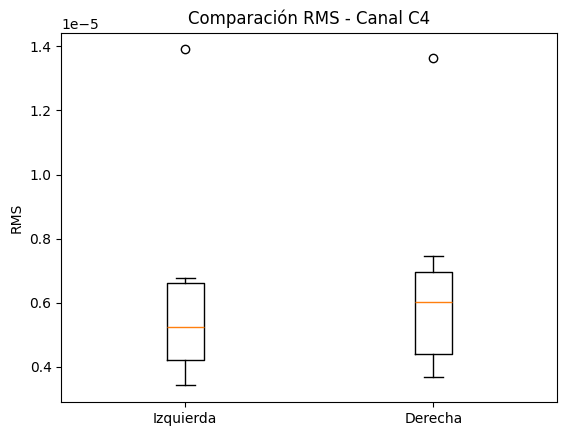

In [ ]:
canal = "C4"
data = [df_izquierda[canal], df_derecha[canal]]
plt.boxplot(data, labels=["Izquierda", "Derecha"])
plt.title(f"Comparación RMS - Canal {canal}")
plt.ylabel("RMS")
plt.show()

La visualización mediante boxplots complementa el análisis numérico, ya que permite ver dispersión, mediana, rango intercuartílico y posibles diferencias entre grupos. En señales EEG, este tipo de representación es especialmente útil porque muchas veces las diferencias entre condiciones no se aprecian fácilmente en el dominio temporal, pero sí en su distribución estadística.


#Conclusiones

A partir de la tabla de resultados presentada, se puede concluir que la gran mayoría de los canales no muestran diferencias estadísticamente significativas entre las condiciones de imaginación de mano izquierda y mano derecha. Esto se evidencia en los valores p elevados (cercanos a 1) obtenidos mediante la prueba t en casi todos los canales, lo que indica que no hay suficiente evidencia para rechazar la hipótesis nula de igualdad de medias.

Sin embargo, un resultado importante es que el canal C4 presentó el menor valor p y fue analizado mediante la prueba de Mann-Whitney, lo cual sugiere dos cosas clave:

Los datos en ese canal no cumplían con los supuestos de normalidad, por eso se utilizó una prueba no paramétrica.
A pesar de que el valor p es el más bajo en comparación con los demás canales, sigue siendo necesario evaluar si realmente es significativo (dependiendo del umbral, usualmente 0.05).

Desde el punto de vista fisiológico, este resultado tiene sentido, ya que C4 está asociado al hemisferio derecho del cerebro, el cual controla el lado izquierdo del cuerpo. En tareas de imaginería motora, es esperable que este canal sea uno de los más sensibles a cambios entre condiciones.

En conjunto, el análisis sugiere que:

No hay diferencias globales fuertes entre imaginar la mano izquierda y la derecha en todos los canales.
Las posibles diferencias son locales, concentradas en canales específicos como C4.
El uso de pruebas estadísticas adecuadas (t-test o Mann-Whitney) es fundamental para obtener conclusiones válidas según la naturaleza de los datos.

Finalmente, aunque C4 destaca como el canal con mayor evidencia de diferencia, los valores p en general indican que las diferencias son sutiles, lo cual es consistente con la naturaleza de las señales EEG en tareas de imaginería motora, donde los cambios suelen ser pequeños y dependientes del sujeto.